In [1]:
%%capture --no-stderr
%pip install --quiet -U databricks-langchain langchain_core langgraph langgraph-prebuilt
dbutils.library.restartPython()

NameError: name 'dbutils' is not defined

In [0]:
# import os
# os.environ['LANGSMITH_API_KEY'] = dbutils.secrets.get(scope="eo_scope", key="LANGSMITH_KEY")
# os.environ['LANGSMITH_TRACING'] = "true"
# os.environ['LANGSMITH_TRACING_V2'] = "true"
# os.environ['LANGSMITH_PROJECT'] = "langchain-academy-module1"
# os.environ['LANGSMITH_ENDPOINT'] = "https://api.smith.langchain.com"

In [2]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

In [3]:
from databricks_langchain import ChatDatabricks
llm = ChatDatabricks(model='agents-demo-gpt4o')

In [5]:
def multiply(a: int, b: int) -> int:
  """
  multiply a and b

  Args:
    a: first number
    b: second number
  """
  return a * b

def add(a: int, b: int) -> int:
  """
  add a and b

  Args:
    a: first number
    b: second number
  """
  return a + b

def divide(a: int, b: int) -> float:
  """
  divide a and b

  Args:
    a: first number
    b: second number
  """
  return a / b

def subtract(a: int, b: int) -> int:
  """
  subtract a and b

  Args:
    a: first number
    b: second number
  """
  return a - b

In [6]:
llm_with_tools = llm.bind_tools([multiply, add, divide, subtract])

In [38]:
def add_system_prompt_node(state: MessagesState) -> MessagesState:
    system_prompt = SystemMessage(content='You are a helpful assistant tasked with doing arithmatic operations on set of inputs.')
  
    return {'messages' : [system_prompt] + state['messages']}

In [39]:
def assistant_node(state: MessagesState) -> MessagesState:
  
  return {'messages' : [llm_with_tools.invoke(state['messages'])]}

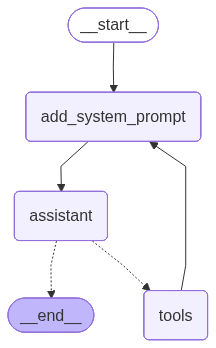

In [44]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
graph = StateGraph(MessagesState)

graph.add_node('add_system_prompt', add_system_prompt_node)
graph.add_node('assistant', assistant_node)
graph.add_node('tools', ToolNode([multiply, add, divide, subtract]))

graph.add_edge(START, 'add_system_prompt')
graph.add_edge('add_system_prompt', 'assistant')
graph.add_conditional_edges('assistant', tools_condition)
graph.add_edge('tools', 'add_system_prompt')

app = graph.compile()
app

In [45]:
# config = {'configurabe': {'thread_id': 1}}
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = app.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================ System Message ================================

You are a helpful assistant tasked with doing arithmatic operations on set of inputs.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_sKp2jmYy1vmHD6MckL0nJ4NO)
 Call ID: call_sKp2jmYy1vmHD6MckL0nJ4NO
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
================================ System Message ================================

You are a helpful assistant tasked with doing arithmatic operations on set of inputs.
================================== Ai Message ==================================

2 multiplied by 2 equals 4.


In [46]:
# config = {'configurabe': {'thread_id': 1}}
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = app.stream({"messages": messages}, stream_mode='values')
for i, chunk in enumerate(messages):
    print(f'|||||||||||||||||||||||||||||||||||-----state: {i}-----|||||||||||||||||||||||||||||||||||||||||||')
    for m in chunk['messages']:
        m.pretty_print()
    # m.pretty_print()

|||||||||||||||||||||||||||||||||||-----state: 0-----|||||||||||||||||||||||||||||||||||||||||||
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
|||||||||||||||||||||||||||||||||||-----state: 1-----|||||||||||||||||||||||||||||||||||||||||||
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================ System Message ================================

You are a helpful assistant tasked with doing arithmatic operations on set of inputs.
|||||||||||||||||||||||||||||||||||-----state: 2-----|||||||||||||||||||||||||||||||||||||||||||
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================ System Message ================================

You are a helpful assistant tasked with doing arithmatic operations on set of inputs.
=========================

In [0]:
messages = [HumanMessage(content="Hello, what is 3 multiplied by 4, subtracted by 2 and devided by 5?")]
messages = app.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

In [0]:
messages = [HumanMessage(content="Now multiply that by 3.")]
messages = app.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()